**One-month training sensitivity experiment**

In addition to the main models trained with all available historical data, a one-month sensitivity experiment was conducted. This experiment uses only March 2026 data and applies a chronological train-validation-test split within this limited period. The purpose is to evaluate whether the LSTM model can still provide useful short-term forecasts when only a limited amount of recent data is available, which is relevant for a potential online deployment scenario.

**LSA10**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# SETTINGS
# ============================================================

LSA_NAME = "LSA10"
MONTH_START = "2026-03-01"
MONTH_END   = "2026-04-01"

LOOKBACK = 4
HORIZON = 1

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
APPROACH_CSV = BASE_DIR / LSA_NAME / f"{LSA_NAME}_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)
df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [col for col in df.columns if col.endswith("_count")]

data = df[["timestamp_berlin"] + count_cols].copy()
data[count_cols] = data[count_cols].ffill().bfill()

# ============================================================
# FILTER ONE MONTH
# ============================================================

month_df = data[
    (data["timestamp_berlin"] >= MONTH_START) &
    (data["timestamp_berlin"] < MONTH_END)
].copy()

print("One-month data shape:", month_df.shape)
print("Time range:", month_df["timestamp_berlin"].min(), "to", month_df["timestamp_berlin"].max())
print("Features:", count_cols)

# ============================================================
# CHRONOLOGICAL SPLIT
# ============================================================

n = len(month_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = month_df.iloc[:train_end].copy()
val_df   = month_df.iloc[train_end:val_end].copy()
test_df  = month_df.iloc[val_end:].copy()

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTime ranges:")
print("Train:", train_df["timestamp_berlin"].min(), "to", train_df["timestamp_berlin"].max())
print("Val:  ", val_df["timestamp_berlin"].min(), "to", val_df["timestamp_berlin"].max())
print("Test: ", test_df["timestamp_berlin"].min(), "to", test_df["timestamp_berlin"].max())

# ============================================================
# SCALING
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[count_cols])

train_scaled = scaler.transform(train_df[count_cols])
val_scaled   = scaler.transform(val_df[count_cols])
test_scaled  = scaler.transform(test_df[count_cols])

# ============================================================
# SEQUENCE GENERATION
# ============================================================

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK, HORIZON)
X_val, y_val     = create_sequences(val_scaled, LOOKBACK, HORIZON)
X_test, y_test   = create_sequences(test_scaled, LOOKBACK, HORIZON)

print("\nSequence shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
print("X_test: ", X_test.shape, "y_test:", y_test.shape)

# ============================================================
# NAIVE BASELINE
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y_pred_naive_scaled = X_test[:, -1, :]

y_test_actual = scaler.inverse_transform(y_test)
y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
overall_rmse_naive = rmse(y_test_actual, y_pred_naive_actual)

# ============================================================
# LSTM
# ============================================================

n_features = X_train.shape[2]

model = Sequential([
    Input(shape=(LOOKBACK, n_features)),
    LSTM(64),
    Dropout(0.2),
    Dense(n_features)
])

model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ============================================================
# EVALUATION
# ============================================================

y_pred_lstm_scaled = model.predict(X_test)
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm_scaled)

overall_mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
overall_rmse_lstm = rmse(y_test_actual, y_pred_lstm_actual)

print("\nOne-month experiment:", LSA_NAME)
print("Naive MAE :", round(overall_mae_naive, 3))
print("Naive RMSE:", round(overall_rmse_naive, 3))

print("\nLSTM MAE :", round(overall_mae_lstm, 3))
print("LSTM RMSE:", round(overall_rmse_lstm, 3))

print("\nImprovement:")
print("MAE improvement (%):", round((overall_mae_naive - overall_mae_lstm) / overall_mae_naive * 100, 2))
print("RMSE improvement (%):", round((overall_rmse_naive - overall_rmse_lstm) / overall_rmse_naive * 100, 2))

One-month data shape: (2935, 6)
Time range: 2026-03-01 01:15:00 to 2026-03-31 23:45:00
Features: ['LSA10_west_count', 'LSA10_south_count', 'LSA10_east_count', 'LSA10_north_west_count', 'LSA10_north_east_count']

Split sizes:
Train: (2054, 6)
Validation: (440, 6)
Test: (441, 6)

Time ranges:
Train: 2026-03-01 01:15:00 to 2026-03-22 15:45:00
Val:   2026-03-22 16:00:00 to 2026-03-27 07:30:00
Test:  2026-03-27 07:45:00 to 2026-03-31 23:45:00

Sequence shapes:
X_train: (2050, 4, 5) y_train: (2050, 5)
X_val:   (436, 4, 5) y_val: (436, 5)
X_test:  (437, 4, 5) y_test: (437, 5)
Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0624 - val_loss: 0.0112
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0128 - val_loss: 0.0098
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - val_loss: 0.0093
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097 - val_loss: 0.0088
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0090 - val_loss: 0.0087
Epoc

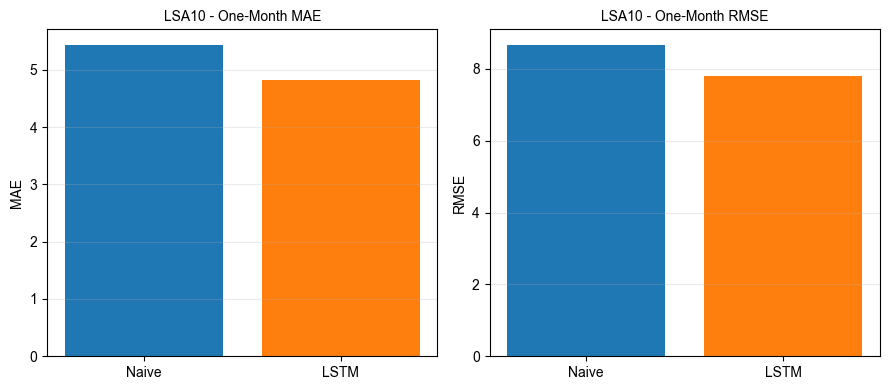

In [2]:
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
import pandas as pd

metrics_df = pd.DataFrame({
    "model": ["Naive", "LSTM"],
    "MAE": [overall_mae_naive, overall_mae_lstm],
    "RMSE": [overall_rmse_naive, overall_rmse_lstm]
})

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(metrics_df["model"], metrics_df["MAE"], color=["tab:blue", "tab:orange"])
axes[0].set_title(f"{LSA_NAME} - One-Month MAE")
axes[0].set_ylabel("MAE")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(metrics_df["model"], metrics_df["RMSE"], color=["tab:blue", "tab:orange"])
axes[1].set_title(f"{LSA_NAME} - One-Month RMSE")
axes[1].set_ylabel("RMSE")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

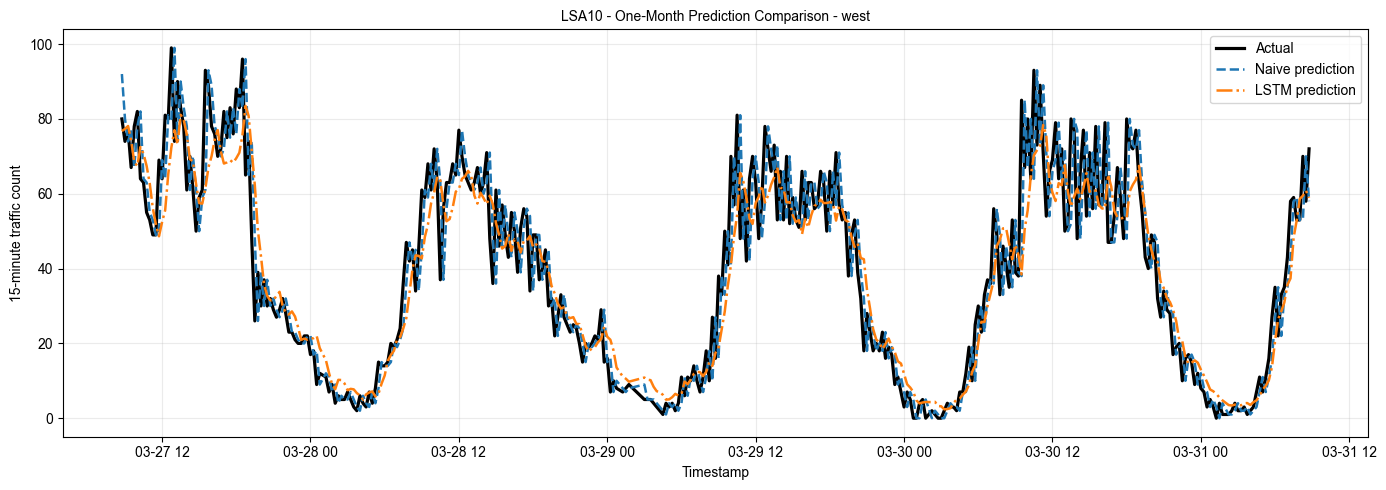

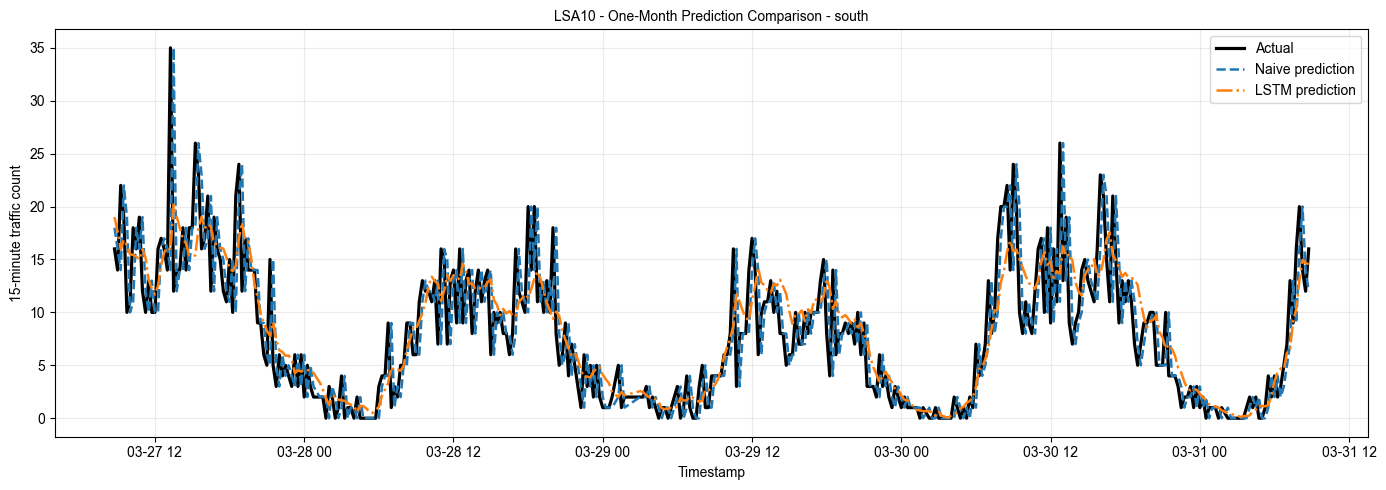

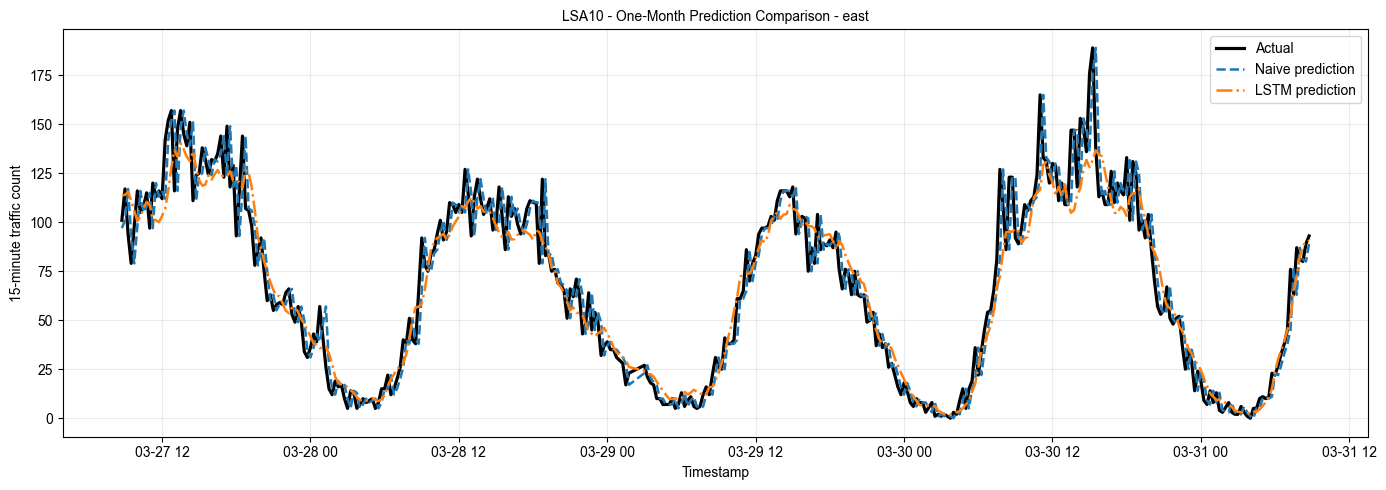

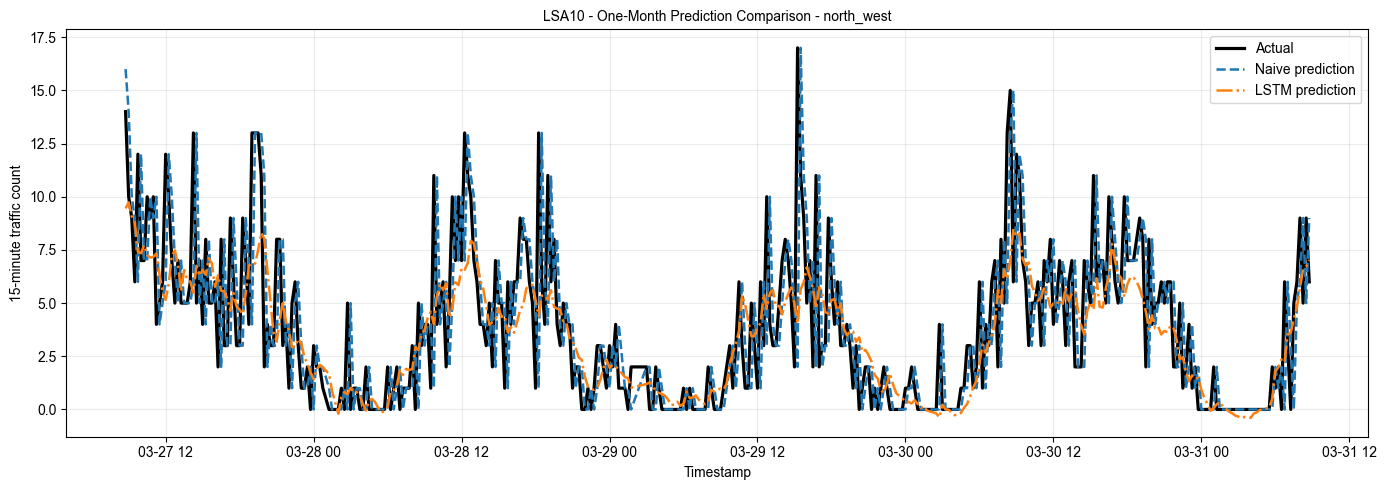

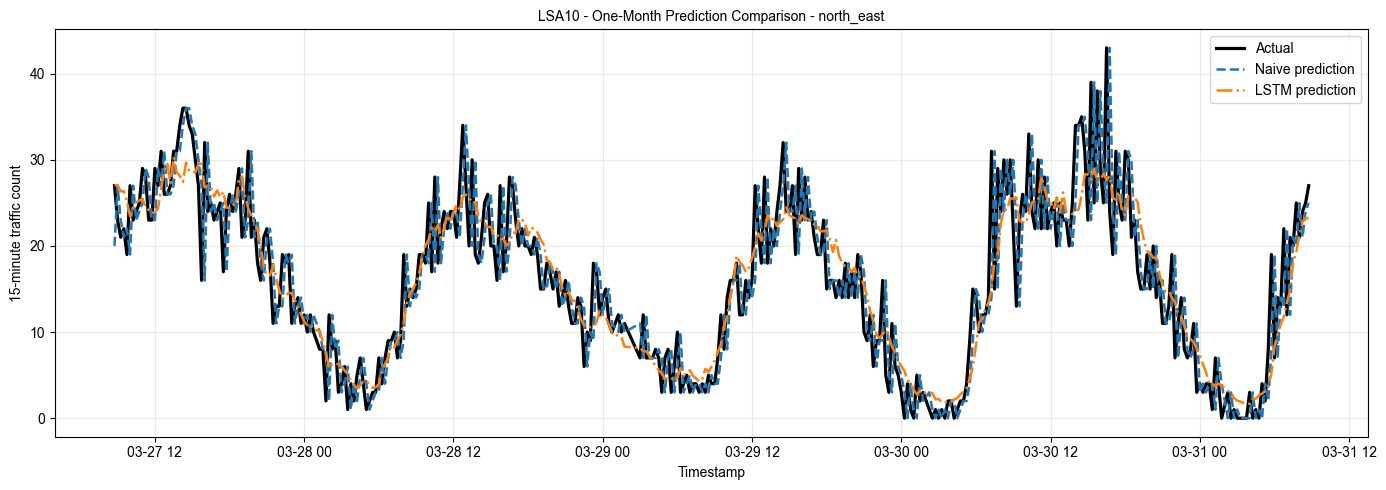

In [4]:
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
import pandas as pd

full_test_timestamps = test_df["timestamp_berlin"].reset_index(drop=True)

aligned_test_timestamps = full_test_timestamps.iloc[
    LOOKBACK + HORIZON - 1 : LOOKBACK + HORIZON - 1 + len(y_test_actual)
].reset_index(drop=True)

window_start = aligned_test_timestamps.min()
window_end = window_start + pd.Timedelta(days=4)

mask = (aligned_test_timestamps >= window_start) & (aligned_test_timestamps <= window_end)

for feature in count_cols:
    idx = count_cols.index(feature)

    plt.figure(figsize=(14, 5))

    plt.plot(
        aligned_test_timestamps[mask],
        y_test_actual[mask, idx],
        label="Actual",
        color="black",
        linewidth=2.3
    )

    plt.plot(
        aligned_test_timestamps[mask],
        y_pred_naive_actual[mask, idx],
        label="Naive prediction",
        color="tab:blue",
        linestyle="--",
        linewidth=1.8
    )

    plt.plot(
        aligned_test_timestamps[mask],
        y_pred_lstm_actual[mask, idx],
        label="LSTM prediction",
        color="tab:orange",
        linestyle="-.",
        linewidth=1.8
    )

    plt.title(f"{LSA_NAME} - One-Month Prediction Comparison - {feature.replace(LSA_NAME + '_', '').replace('_count', '')}")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()